# Compare Communication Regimes: FFN vs RNN Two-Module (Rich)

This notebook compares **two-module FFN** and **two-module RNN** (GRU) under rich embedding (γ=1e-3), across communication regimes.

1. **Task Regimes**: same, near, far
2. **Communication Regimes**: none, low, high
3. **Architecture**: FFN (`two_module_rich_50_*`) vs RNN (`two_module_rnn_rich_50_*`)

**Configurations**: `two_module_rich_50_{none,low,high}` and `two_module_rnn_rich_50_{none,low,high}`.

All analysis figures are generated **separately for FFN and RNN**, and each figure title/filename includes the architecture label.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Setup path
SCRIPT_DIR = Path(__file__).parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent  # transfer-interference directory
sys.path.insert(0, str(PROJECT_ROOT))

# Imports from project
from src.analysis import ann
from src.utils import figure_settings, figure_utils
from src.utils.figure_settings import schedule_colours, cm_conv, med_fontsize

# Setup figure output
figure_path = PROJECT_ROOT / "figures" / "compare_communication_regimes"
os.makedirs(figure_path, exist_ok=True)

# Set style
plt.style.use("default")
sns.set_palette("husl")
print("✓ Imports completed")

✓ Imports completed


## 1. Setup and Data Loading

Load data from all three communication regime conditions.

In [2]:
# FFN and RNN configuration names (rich_50 only)
configs_ffn = {
    'none': 'two_module_rich_50_none',
    'low': 'two_module_rich_50_low',
    'high': 'two_module_rich_50_high'
}
configs_rnn = {
    'none': 'two_module_rnn_rich_50_none',
    'low': 'two_module_rnn_rich_50_low',
    'high': 'two_module_rnn_rich_50_high'
}

# Color scheme: comm_type
comm_colors = {
    'none': '#808080',
    'low': '#56B4E9',
    'high': '#D9544D'
}
# Architecture colors for FFN vs RNN
arch_colors = {'FFN': '#2ca02c', 'RNN': '#ff7f0e'}

# Load FFN data
ann_data_ffn = {}
for comm_type, config_name in configs_ffn.items():
    data_path = PROJECT_ROOT / 'data' / 'simulations' / config_name
    if data_path.exists():
        ann_data_ffn[comm_type] = ann.load_ann_data(str(data_path))
        print(f"✓ FFN {config_name}: {len(ann_data_ffn[comm_type]['same'])} participants")
    else:
        print(f"⚠ FFN {config_name} not found")
        ann_data_ffn[comm_type] = {'same': [], 'near': [], 'far': []}

# Load RNN data
ann_data_rnn = {}
for comm_type, config_name in configs_rnn.items():
    data_path = PROJECT_ROOT / 'data' / 'simulations' / config_name
    if data_path.exists():
        ann_data_rnn[comm_type] = ann.load_ann_data(str(data_path))
        print(f"✓ RNN {config_name}: {len(ann_data_rnn[comm_type]['same'])} participants")
    else:
        print(f"⚠ RNN {config_name} not found")
        ann_data_rnn[comm_type] = {'same': [], 'near': [], 'far': []}

# Combined dict keyed by architecture for unified iteration
ann_data_by_arch = {'FFN': ann_data_ffn, 'RNN': ann_data_rnn}
# For downstream cells (learning curves, activations, principal angles) use FFN; task-switching cell uses both.
ann_data = ann_data_ffn
print(f"\nLoaded FFN and RNN data for 3 communication regimes each.")

✓ FFN two_module_rich_50_none: 103 participants
✓ FFN two_module_rich_50_low: 103 participants
✓ FFN two_module_rich_50_high: 103 participants
✓ RNN two_module_rnn_rich_50_none: 103 participants
✓ RNN two_module_rnn_rich_50_low: 103 participants
✓ RNN two_module_rnn_rich_50_high: 103 participants

Loaded FFN and RNN data for 3 communication regimes each.


## 2. Task Switching Analysis

Analyze transfer costs and interference at task boundaries (A1→B, B→A2).

Transfer metrics (by architecture and comm_type):
                        count      mean       std       min       25%  \
architecture comm_type                                                  
FFN          high       305.0 -0.500598  0.116449 -0.772797 -0.584010   
             low        305.0 -0.501309  0.115164 -0.781915 -0.580232   
             none       305.0 -0.498755  0.122876 -0.811823 -0.584961   
RNN          high       305.0 -0.500461  0.032999 -0.600228 -0.524273   
             low        305.0 -0.500448  0.032991 -0.600208 -0.524275   
             none       305.0 -0.500413  0.033557 -0.596383 -0.523291   

                             50%       75%       max  
architecture comm_type                                
FFN          high      -0.500144 -0.415167 -0.211273  
             low       -0.499231 -0.417608 -0.215769  
             none      -0.498310 -0.407951 -0.199660  
RNN          high      -0.498132 -0.476880 -0.417535  
             low       -0.498127 -0

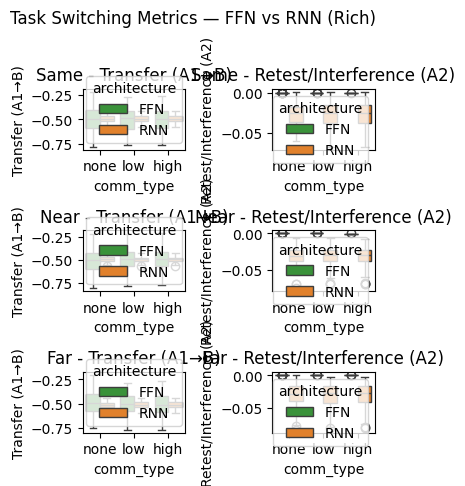

In [3]:
def compute_retest_metrics(ann_data_dict):
    """Compute retest/interference metrics (A1 vs A2 performance)."""
    agg_data = []
    
    for comm_type, data in ann_data_dict.items():
        for schedule_name, schedule_data in data.items():
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                # Get accuracy by task section (winter responses only, feature_idx==1)
                A1_accuracy = subj_data['accuracy'][0, 1::2].copy()  # Phase 0, every other (winter)
                A2_accuracy = subj_data['accuracy'][2, 1::2].copy()  # Phase 2, every other (winter)
                
                # Average over relevant windows
                final_A1_acc = np.mean(A1_accuracy[-6:])  # final 6 trials of A1
                initial_A2_acc = np.mean(A2_accuracy[0:6])  # first 6 trials of A2
                mean_A2_acc = np.mean(A2_accuracy)  # overall A2 performance
                
                # Calculate retest/interference metrics
                retest_error_diff = initial_A2_acc - final_A1_acc  # Initial A2 vs final A1
                interference = final_A1_acc - mean_A2_acc  # Final A1 vs mean A2
                
                agg_data.append({
                    'participant': str(subj_data['participant']),
                    'condition': schedule_name,
                    'comm_type': comm_type,
                    'final_A1_acc': final_A1_acc,
                    'initial_A2_acc': initial_A2_acc,
                    'mean_A2_acc': mean_A2_acc,
                    'retest_error_diff': retest_error_diff,
                    'interference': interference
                })
    
    return pd.DataFrame(agg_data)

# Compute transfer and retest metrics for FFN and RNN
transfer_dfs = {}

for arch_name, data_dict in ann_data_by_arch.items():
    for comm_type, data in data_dict.items():
        if len(data.get('same', [])) > 0:
            td = ann.compute_transfer_anns(data)
            td['comm_type'] = comm_type
            td['architecture'] = arch_name
            transfer_dfs[(arch_name, comm_type)] = td

if transfer_dfs:
    transfer_combined = pd.concat(transfer_dfs.values(), ignore_index=True)
    transfer_combined.rename(columns={'error_diff': 'transfer_error_diff'}, inplace=True)
    retest_combined = pd.concat([
        compute_retest_metrics(ann_data_ffn).assign(architecture='FFN'),
        compute_retest_metrics(ann_data_rnn).assign(architecture='RNN')
    ], ignore_index=True)
    print("Transfer metrics (by architecture and comm_type):")
    print(transfer_combined.groupby(['architecture', 'comm_type'])['transfer_error_diff'].describe())
    print("\nRetest metrics:")
    print(retest_combined.groupby(['architecture', 'comm_type'])['retest_error_diff'].describe())
else:
    transfer_combined = None
    retest_combined = None
    print("No data available")

if transfer_combined is not None and len(transfer_combined) > 0:
    task_regimes = ['same', 'near', 'far']
    task_labels = ['Same', 'Near', 'Far']
    comm_order = ['none', 'low', 'high']
    fig, axes = plt.subplots(len(task_regimes), 2, figsize=(10*cm_conv, 4*len(task_regimes)*cm_conv))
    for row, (regime, rlabel) in enumerate(zip(task_regimes, task_labels)):
        for col, (metric, mlabel) in enumerate([('transfer_error_diff', 'Transfer (A1→B)'), ('retest_error_diff', 'Retest/Interference (A2)')]):
            ax = axes[row, col]
            df = transfer_combined if metric == 'transfer_error_diff' else retest_combined
            sub = df[df['condition'] == regime]
            if len(sub) > 0:
                sns.boxplot(data=sub, x='comm_type', y=metric, hue='architecture', ax=ax, order=comm_order, palette=arch_colors)
            ax.set_title(f"{rlabel} - {mlabel}")
            ax.set_ylabel(mlabel)
    plt.suptitle('Task Switching Metrics — FFN vs RNN (Rich)', y=1.02)
    plt.tight_layout()
    plt.savefig(figure_path / 'task_switching_metrics_ffn_rnn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No data available for visualization")


In [4]:
# Visualize transfer and retest metrics

In [5]:
def extract_learning_curves(ann_data_dict, phase_idx=0, metric='accuracy', feature_idx=1):
    """Extract learning curves for a specific phase, preserving task regime information."""
    curves = {}

    # Structure: curves[comm_type][task_regime] = list of curves
    for comm_type, data in ann_data_dict.items():
        curves[comm_type] = {}
        for schedule_name, schedule_data in data.items():
            curves[comm_type][schedule_name] = []
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                if metric == 'accuracy':
                    # Extract accuracy for specific feature (winter: feature_idx=1)
                    curve = subj_data['accuracy'][phase_idx, feature_idx::2].copy()
                elif metric == 'loss':
                    curve = subj_data['losses'][phase_idx, :].copy()
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                curves[comm_type][schedule_name].append(curve)

    return curves

# Extract learning curves for each phase, for both architectures
phases = {'A1': 0, 'B': 1, 'A2': 2}
learning_curves_by_arch = {}

for arch_name, data_dict in ann_data_by_arch.items():
    lc = {}
    for phase_name, phase_idx in phases.items():
        lc[phase_name] = {
            'accuracy': extract_learning_curves(data_dict, phase_idx, 'accuracy'),
            'loss': extract_learning_curves(data_dict, phase_idx, 'loss')
        }
    learning_curves_by_arch[arch_name] = lc

print(f"Learning curves extracted for architectures: {list(learning_curves_by_arch.keys())}")

Learning curves extracted for architectures: ['FFN', 'RNN']


In [6]:
def extract_module_activations(ann_data_dict):
    """Extract module activation statistics per phase, preserving task regime information."""
    activation_stats = {}
    
    for comm_type, data in ann_data_dict.items():
        activation_stats[comm_type] = {}
        
        for schedule_name, schedule_data in data.items():
            activation_stats[comm_type][schedule_name] = {
                'A1': {'mod_A': [], 'mod_B': []},
                'B': {'mod_A': [], 'mod_B': []},
                'A2': {'mod_A': [], 'mod_B': []}
            }
            
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                # Check if per-module hidden states exist
                if 'hiddens_A' in subj_data and 'hiddens_B' in subj_data:
                    h_A = subj_data['hiddens_A']  # (n_phase, n_trials, dim_hidden_per_module)
                    h_B = subj_data['hiddens_B']
                    
                    for phase_idx, phase_name in enumerate(['A1', 'B', 'A2']):
                        if h_A.shape[0] > phase_idx:
                            # Compute activation magnitude (L2 norm) for each trial
                            mod_A_activations = np.linalg.norm(h_A[phase_idx, :, :], axis=1)
                            mod_B_activations = np.linalg.norm(h_B[phase_idx, :, :], axis=1)
                            
                            activation_stats[comm_type][schedule_name][phase_name]['mod_A'].append(mod_A_activations)
                            activation_stats[comm_type][schedule_name][phase_name]['mod_B'].append(mod_B_activations)
    
    return activation_stats

# Extract activation statistics for both architectures
activation_stats_by_arch = {}
for arch_name, data_dict in ann_data_by_arch.items():
    activation_stats_by_arch[arch_name] = extract_module_activations(data_dict)

print(f"Module activation statistics extracted for architectures: {list(activation_stats_by_arch.keys())}")

Module activation statistics extracted for architectures: ['FFN', 'RNN']


In [ ]:
# Plot learning curves - split by task regime (FFN and RNN)
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']

for arch_name, learning_curves in learning_curves_by_arch.items():
    # Accuracy curves: rows = task regimes, columns = phases
    fig_acc, axes_acc = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes_acc = axes_acc.reshape(1, -1)

    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
            ax = axes_acc[task_idx, phase_idx]
            for comm_type in ['none', 'low', 'high']:
                if comm_type in learning_curves[phase_name]['accuracy']:
                    if task_regime in learning_curves[phase_name]['accuracy'][comm_type]:
                        curves = learning_curves[phase_name]['accuracy'][comm_type][task_regime]
                        if len(curves) > 0:
                            min_len = min(len(c) for c in curves)
                            curves_aligned = [c[:min_len] for c in curves]
                            curves_array = np.array(curves_aligned)

                            mean_curve = np.mean(curves_array, axis=0)
                            std_curve = np.std(curves_array, axis=0)
                            x = np.arange(len(mean_curve))

                            ax.plot(x, mean_curve, color=comm_colors[comm_type],
                                   label=comm_type, linewidth=1.5)
                            ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                           color=comm_colors[comm_type], alpha=0.2)

            ax.set_xlabel('Trial')
            if task_idx == 0:
                ax.set_title(f'{phase_name} Phase')
            if phase_idx == 0:
                ax.set_ylabel(f'{task_label}\nAccuracy')
            else:
                ax.set_ylabel('Accuracy')
            if task_idx == 0 and phase_idx == len(phases) - 1:
                ax.legend()
            ax.grid(True, alpha=0.3)
            figure_utils._style_axes(ax)

    plt.suptitle(f'Learning Curves (Accuracy) — {arch_name}', y=1.02)
    plt.tight_layout()
    plt.savefig(figure_path / f'learning_curves_accuracy_{arch_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Loss curves: rows = task regimes, columns = phases
    fig_loss, axes_loss = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes_loss = axes_loss.reshape(1, -1)

    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
            ax = axes_loss[task_idx, phase_idx]
            for comm_type in ['none', 'low', 'high']:
                if comm_type in learning_curves[phase_name]['loss']:
                    if task_regime in learning_curves[phase_name]['loss'][comm_type]:
                        curves = learning_curves[phase_name]['loss'][comm_type][task_regime]
                        if len(curves) > 0:
                            min_len = min(len(c) for c in curves)
                            curves_aligned = [c[:min_len] for c in curves]
                            curves_array = np.array(curves_aligned)

                            mean_curve = np.mean(curves_array, axis=0)
                            std_curve = np.std(curves_array, axis=0)
                            x = np.arange(len(mean_curve))

                            ax.plot(x, mean_curve, color=comm_colors[comm_type],
                                   label=comm_type, linewidth=1.5)
                            ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                           color=comm_colors[comm_type], alpha=0.2)

            ax.set_xlabel('Trial')
            if task_idx == 0:
                ax.set_title(f'{phase_name} Phase')
            if phase_idx == 0:
                ax.set_ylabel(f'{task_label}\nLoss')
            else:
                ax.set_ylabel('Loss')
            if task_idx == 0 and phase_idx == len(phases) - 1:
                ax.legend()
            ax.grid(True, alpha=0.3)
            figure_utils._style_axes(ax)

    plt.suptitle(f'Learning Curves (Loss) — {arch_name}', y=1.02)
    plt.tight_layout()
    plt.savefig(figure_path / f'learning_curves_loss_{arch_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()mns = phases
fig_loss, axes_loss = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
if len(task_regimes) == 1:
    axes_loss = axes_loss.reshape(1, -1)

for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
    for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
        ax = axes_loss[task_idx, phase_idx]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in learning_curves[phase_name]['loss']:
                if task_regime in learning_curves[phase_name]['loss'][comm_type]:
                    curves = learning_curves[phase_name]['loss'][comm_type][task_regime]
                    if len(curves) > 0:
                        min_len = min(len(c) for c in curves)
                        curves_aligned = [c[:min_len] for c in curves]
                        curves_array = np.array(curves_aligned)
                        
                        mean_curve = np.mean(curves_array, axis=0)
                        std_curve = np.std(curves_array, axis=0)
                        x = np.arange(len(mean_curve))
                        
                        ax.plot(x, mean_curve, color=comm_colors[comm_type],
                               label=comm_type, linewidth=1.5)
                        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                       color=comm_colors[comm_type], alpha=0.2)
        
        ax.set_xlabel('Trial')
        if task_idx == 0:
            ax.set_title(f'{phase_name} Phase')
        if phase_idx == 0:
            ax.set_ylabel(f'{task_label}\nLoss')
        else:
            ax.set_ylabel('Loss')
        if task_idx == 0 and phase_idx == len(phases) - 1:
            ax.legend()
        ax.grid(True, alpha=0.3)
        figure_utils._style_axes(ax)

plt.tight_layout()
# Legacy save removed: loss curves are saved per-architecture above.
plt.show()

SyntaxError: invalid syntax (2320598073.py, line 90)

In [ ]:
# Visualize module activations - split by task regime (FFN and RNN)
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']
phases_list = ['A1', 'B', 'A2']

for arch_name, activation_stats in activation_stats_by_arch.items():
    has_data = False
    if activation_stats:
        for comm_type in activation_stats:
            for task_regime in task_regimes:
                if task_regime in activation_stats[comm_type]:
                    if len(activation_stats[comm_type][task_regime]['A1']['mod_A']) > 0:
                        has_data = True
                        break
            if has_data:
                break

    if has_data:
        fig, axes = plt.subplots(len(task_regimes), len(phases_list), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
        if len(task_regimes) == 1:
            axes = axes.reshape(1, -1)

        for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
            for phase_idx, phase_name in enumerate(phases_list):
                ax = axes[task_idx, phase_idx]

                mod_A_means = []
                mod_A_stds = []
                mod_B_means = []
                mod_B_stds = []
                comm_types_present = []

                for comm_type in ['none', 'low', 'high']:
                    if comm_type in activation_stats and task_regime in activation_stats[comm_type]:
                        if len(activation_stats[comm_type][task_regime][phase_name]['mod_A']) > 0:
                            all_A = np.concatenate(activation_stats[comm_type][task_regime][phase_name]['mod_A'])
                            all_B = np.concatenate(activation_stats[comm_type][task_regime][phase_name]['mod_B'])

                            mod_A_means.append(np.mean(all_A))
                            mod_A_stds.append(np.std(all_A))
                            mod_B_means.append(np.mean(all_B))
                            mod_B_stds.append(np.std(all_B))
                            comm_types_present.append(comm_type)

                if len(comm_types_present) > 0:
                    x = np.arange(len(comm_types_present))
                    width = 0.35

                    ax.bar(x - width/2, mod_A_means, width, yerr=mod_A_stds,
                           label='Module A', color='#b08cca', alpha=0.7, capsize=5)
                    ax.bar(x + width/2, mod_B_means, width, yerr=mod_B_stds,
                           label='Module B', color='#aad39b', alpha=0.7, capsize=5)

                    ax.set_xticks(x)
                    ax.set_xticklabels(comm_types_present)
                    if task_idx == 0:
                        ax.set_title(f'{phase_name} Phase')
                    if phase_idx == 0:
                        ax.set_ylabel(f'{task_label}\nActivation Magnitude')
                    else:
                        ax.set_ylabel('Activation Magnitude')
                    if task_idx == 0 and phase_idx == len(phases_list) - 1:
                        ax.legend()
                    figure_utils._style_axes(ax)

        plt.suptitle(f'Module Activations — {arch_name}', y=1.02)
        plt.tight_layout()
        plt.savefig(figure_path / f'module_activations_{arch_name.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"No module activation data available for {arch_name}")

No module activation data available


## 5. Representational Geometry Analysis

Compare principal angles and PCA visualizations across communication regimes.

In [ ]:
# Analyze cross-module activation (inactive module receiving communication)
def analyze_cross_module_activation(ann_data_dict):
    """Analyze how much inactive modules activate via communication.

    Returns:
        cross_activation[comm_type][task_regime]['A_active_B_receives' | 'B_active_A_receives'] -> list[float]
    """
    cross_activation = {}

    for comm_type, data in ann_data_dict.items():
        cross_activation[comm_type] = {}

        for task_regime, schedule_data in data.items():
            cross_activation[comm_type][task_regime] = {
                'A_active_B_receives': [],
                'B_active_A_receives': [],
            }

            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]

                if 'hiddens_A' in subj_data and 'hiddens_B' in subj_data:
                    h_A = subj_data['hiddens_A']
                    h_B = subj_data['hiddens_B']

                    for phase_idx in [0, 2]:
                        if h_B.shape[0] > phase_idx:
                            mod_B_acts = np.linalg.norm(h_B[phase_idx, :, :], axis=1)
                            cross_activation[comm_type][task_regime]['A_active_B_receives'].extend(mod_B_acts)

                    if h_A.shape[0] > 1:
                        mod_A_acts = np.linalg.norm(h_A[1, :, :], axis=1)
                        cross_activation[comm_type][task_regime]['B_active_A_receives'].extend(mod_A_acts)

    return cross_activation

cross_activation_by_arch = {
    arch_name: analyze_cross_module_activation(data_dict)
    for arch_name, data_dict in ann_data_by_arch.items()
}

task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']

for arch_name, cross_activation in cross_activation_by_arch.items():
    has_data = False
    if cross_activation:
        for comm_type in cross_activation:
            for task_regime in task_regimes:
                if task_regime in cross_activation[comm_type]:
                    if len(cross_activation[comm_type][task_regime]['A_active_B_receives']) > 0:
                        has_data = True
                        break
            if has_data:
                break

    if has_data:
        fig, axes = plt.subplots(len(task_regimes), 2, figsize=(10*cm_conv, 4*len(task_regimes)*cm_conv))
        if len(task_regimes) == 1:
            axes = axes.reshape(1, -1)

        for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
            ax1 = axes[task_idx, 0]
            for comm_type in ['none', 'low', 'high']:
                if comm_type in cross_activation and task_regime in cross_activation[comm_type]:
                    acts = cross_activation[comm_type][task_regime]['A_active_B_receives']
                    if len(acts) > 0:
                        mean_act = np.mean(acts)
                        std_act = np.std(acts)
                        ax1.bar(comm_type, mean_act, color=comm_colors[comm_type], alpha=0.7,
                               yerr=std_act, capsize=5)
            if task_idx == 0:
                ax1.set_title('Cross-Module Communication: A→B')
            ax1.set_ylabel(f'{task_label}\nModule B Activation')
            ax1.set_xticklabels(['none', 'low', 'high'])
            figure_utils._style_axes(ax1)

            ax2 = axes[task_idx, 1]
            for comm_type in ['none', 'low', 'high']:
                if comm_type in cross_activation and task_regime in cross_activation[comm_type]:
                    acts = cross_activation[comm_type][task_regime]['B_active_A_receives']
                    if len(acts) > 0:
                        mean_act = np.mean(acts)
                        std_act = np.std(acts)
                        ax2.bar(comm_type, mean_act, color=comm_colors[comm_type], alpha=0.7,
                               yerr=std_act, capsize=5)
            if task_idx == 0:
                ax2.set_title('Cross-Module Communication: B→A')
            ax2.set_ylabel(f'{task_label}\nModule A Activation')
            ax2.set_xticklabels(['none', 'low', 'high'])
            figure_utils._style_axes(ax2)

        plt.suptitle(f'Cross-Module Activation — {arch_name}', y=1.02)
        plt.tight_layout()
        plt.savefig(figure_path / f'cross_module_activation_{arch_name.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"No cross-module activation data available for {arch_name}")

No cross-module activation data available


Principal angles summary:
          within_task_A                                                        \
                  count       mean        std       min        25%        50%   
comm_type                                                                       
high              305.0  38.953194  18.017641  0.094873  25.649914  43.246090   
low               305.0  38.971012  18.016083  0.081565  25.558149  43.227539   
none              305.0  38.153896  17.616064  0.100871  27.202267  42.130772   

                                within_task_B             ...             \
                 75%        max         count       mean  ...        75%   
comm_type                                                 ...              
high       52.258842  73.640694         305.0  39.172005  ...  51.865433   
low        52.151031  73.610107         305.0  39.207676  ...  51.915459   
none       51.733665  71.842308         305.0  38.471516  ...  51.650715   

                     across_ta

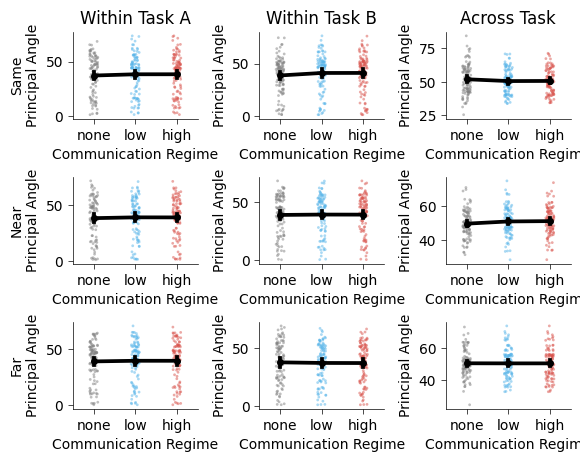

In [ ]:
# Compute principal angles for each condition (FFN and RNN)
pa_combined_by_arch = {}

for arch_name, data_dict in ann_data_by_arch.items():
    principal_angles = {}

    for comm_type, data in data_dict.items():
        if len(data.get('same', [])) > 0:
            pa_df = ann.get_principal_angles(data)
            pa_df['comm_type'] = comm_type
            principal_angles[comm_type] = pa_df

    if principal_angles:
        pa_combined_by_arch[arch_name] = pd.concat(principal_angles.values(), ignore_index=True)

for arch_name, pa_combined in pa_combined_by_arch.items():
    print(f"Principal angles summary — {arch_name}:")
    print(pa_combined.groupby('comm_type')[['within_task_A', 'within_task_B', 'across_task']].describe())

    task_regimes = ['same', 'near', 'far']
    task_labels = ['Same', 'Near', 'Far']
    metrics = ['within_task_A', 'within_task_B', 'across_task']
    metric_labels = ['Within Task A', 'Within Task B', 'Across Task']

    fig, axes = plt.subplots(len(task_regimes), len(metrics), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)

    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for metric_idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
            ax = axes[task_idx, metric_idx]
            pa_task = pa_combined[pa_combined['condition'] == task_regime]
            if len(pa_task) > 0:
                sns.stripplot(data=pa_task, x='comm_type', y=metric,
                              ax=ax, order=['none', 'low', 'high'],
                              palette=[comm_colors[c] for c in ['none', 'low', 'high']],
                              alpha=0.5, size=2, jitter=True, zorder=1)
                sns.pointplot(data=pa_task, x='comm_type', y=metric,
                              ax=ax, order=['none', 'low', 'high'],
                              color='black', markersize=3, zorder=2)
            ax.set_xlabel('Communication Regime')
            if task_idx == 0:
                ax.set_title(label)
            if metric_idx == 0:
                ax.set_ylabel(f'{task_label}\nPrincipal Angle')
            else:
                ax.set_ylabel('Principal Angle')
            figure_utils._style_axes(ax)

    plt.suptitle(f'Principal Angles — {arch_name}', y=1.02)
    plt.tight_layout()
    plt.savefig(figure_path / f'principal_angles_{arch_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

if not pa_combined_by_arch:
    print("No principal angle data available")

## 6. Statistical Comparisons

Perform statistical tests comparing communication regimes.

In [ ]:
def compute_effect_size(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    d = (mean1 - mean2) / pooled_std
    return d

# Statistical comparisons
if 'transfer_combined' in locals() and len(transfer_combined) > 0:
    print("=" * 60)
    print("STATISTICAL COMPARISONS")
    print("=" * 60)
    
    # Transfer cost comparisons
    print("\n1. Transfer Cost (A1→B) Comparisons:")
    print("-" * 60)
    
    transfer_same = transfer_combined[transfer_combined['condition'] == 'same']
    
    for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
        g1 = transfer_same[transfer_same['comm_type'] == comparison[0]]['transfer_error_diff'].values
        g2 = transfer_same[transfer_same['comm_type'] == comparison[1]]['transfer_error_diff'].values
        
        if len(g1) > 0 and len(g2) > 0:
            t_stat, p_val = stats.ttest_ind(g1, g2)
            effect_size = compute_effect_size(g1, g2)
            
            print(f"{comparison[0]} vs {comparison[1]}:")
            print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
            print(f"  Effect size (Cohen's d): {effect_size:.3f}")
            print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
            print()
    
    # Retest/interference comparisons
    if 'retest_combined' in locals() and len(retest_combined) > 0:
        print("\n2. Retest/Interference (A1→A2) Comparisons:")
        print("-" * 60)
        
        retest_same = retest_combined[retest_combined['condition'] == 'same']
        
        for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
            g1 = retest_same[retest_same['comm_type'] == comparison[0]]['retest_error_diff'].values
            g2 = retest_same[retest_same['comm_type'] == comparison[1]]['retest_error_diff'].values
            
            if len(g1) > 0 and len(g2) > 0:
                t_stat, p_val = stats.ttest_ind(g1, g2)
                effect_size = compute_effect_size(g1, g2)
                
                print(f"{comparison[0]} vs {comparison[1]}:")
                print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
                print(f"  Effect size (Cohen's d): {effect_size:.3f}")
                print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
                print()
    
    # Principal angle comparisons
    if 'pa_combined' in locals() and len(pa_combined) > 0:
        print("\n3. Principal Angle Comparisons (Across-Task):")
        print("-" * 60)
        
        pa_same = pa_combined[pa_combined['condition'] == 'same']
        
        for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
            g1 = pa_same[pa_same['comm_type'] == comparison[0]]['across_task'].values
            g2 = pa_same[pa_same['comm_type'] == comparison[1]]['across_task'].values
            
            if len(g1) > 0 and len(g2) > 0:
                t_stat, p_val = stats.ttest_ind(g1, g2)
                effect_size = compute_effect_size(g1, g2)
                
                print(f"{comparison[0]} vs {comparison[1]}:")
                print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
                print(f"  Effect size (Cohen's d): {effect_size:.3f}")
                print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
                print()
else:
    print("No data available for statistical comparisons")

STATISTICAL COMPARISONS

1. Transfer Cost (A1→B) Comparisons:
------------------------------------------------------------
none vs low:
  t-statistic: 0.377, p-value: 0.7061
  Effect size (Cohen's d): 0.037
  Mean difference: 0.0033

none vs high:
  t-statistic: 0.261, p-value: 0.7946
  Effect size (Cohen's d): 0.026
  Mean difference: 0.0023

low vs high:
  t-statistic: -0.118, p-value: 0.9060
  Effect size (Cohen's d): -0.012
  Mean difference: -0.0010


2. Retest/Interference (A1→A2) Comparisons:
------------------------------------------------------------
none vs low:
  t-statistic: -0.094, p-value: 0.9253
  Effect size (Cohen's d): -0.009
  Mean difference: -0.0002

none vs high:
  t-statistic: -0.101, p-value: 0.9200
  Effect size (Cohen's d): -0.010
  Mean difference: -0.0002

low vs high:
  t-statistic: -0.006, p-value: 0.9950
  Effect size (Cohen's d): -0.001
  Mean difference: -0.0000


3. Principal Angle Comparisons (Across-Task):
--------------------------------------------

In [ ]:
# Create summary table (FFN vs RNN)
if 'transfer_combined' in locals() and 'retest_combined' in locals():
    summary_data = []

    for arch_name in ['FFN', 'RNN']:
        for comm_type in ['none', 'low', 'high']:
            transfer_subset = transfer_combined[
                (transfer_combined.get('architecture') == arch_name) &
                (transfer_combined['comm_type'] == comm_type) &
                (transfer_combined['condition'] == 'same')
            ]
            retest_subset = retest_combined[
                (retest_combined.get('architecture') == arch_name) &
                (retest_combined['comm_type'] == comm_type) &
                (retest_combined['condition'] == 'same')
            ]

            if len(transfer_subset) > 0 and len(retest_subset) > 0:
                summary_data.append({
                    'Architecture': arch_name,
                    'Communication Regime': comm_type,
                    'Transfer Cost (A1→B)': f"{np.mean(transfer_subset['transfer_error_diff']):.4f} ± {np.std(transfer_subset['transfer_error_diff']):.4f}",
                    'Interference (A1→A2)': f"{np.mean(retest_subset['retest_error_diff']):.4f} ± {np.std(retest_subset['retest_error_diff']):.4f}",
                    'Final A1 Accuracy': f"{np.mean(retest_subset['final_A1_acc']):.4f} ± {np.std(retest_subset['final_A1_acc']):.4f}",
                    'Mean A2 Accuracy': f"{np.mean(retest_subset['mean_A2_acc']):.4f} ± {np.std(retest_subset['mean_A2_acc']):.4f}",
                })

    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        print("=" * 80)
        print("SUMMARY TABLE (Same regime) — FFN vs RNN")
        print("=" * 80)
        print(summary_df.to_string(index=False))
        print()
    else:
        print("No data available for summary table")
        print("   - Communication may help Module B leverage Module A's knowledge")
        
        print("\n2. Interference (A1→A2):")
        print("   - Measures performance change when returning to Task A after B training")
        print("   - Negative values indicate catastrophic forgetting")
        print("   - Communication may help preserve Module A representations during B training")
        
        print("\n3. Communication Effects:")
        print("   - None: Modules are completely isolated")
        print("   - Low: Minimal information flow (scale=0.05)")
        print("   - High: Strong information flow (scale=0.1)")
        
        print("\n4. Questions to Consider:")
        print("   - Does communication reduce transfer cost?")
        print("   - Does communication prevent catastrophic forgetting?")
        print("   - Are there trade-offs between transfer and interference?")
        print("   - How does communication strength affect these metrics?")
else:
    print("No summary data available")

SUMMARY TABLE
Communication Regime Transfer Cost (A1→B) Interference (A1→A2) Final A1 Accuracy Mean A2 Accuracy
                none     -0.4947 ± 0.0907     -0.0136 ± 0.0170   0.9972 ± 0.0038  0.9969 ± 0.0041
                 low     -0.4980 ± 0.0867     -0.0134 ± 0.0168   0.9972 ± 0.0038  0.9970 ± 0.0039
                high     -0.4970 ± 0.0873     -0.0134 ± 0.0166   0.9972 ± 0.0038  0.9970 ± 0.0039

KEY INSIGHTS

1. Transfer Cost (A1→B):
   - Measures performance drop when switching from Task A to Task B
   - Lower (more negative) values indicate better transfer
   - Communication may help Module B leverage Module A's knowledge

2. Interference (A1→A2):
   - Measures performance change when returning to Task A after B training
   - Negative values indicate catastrophic forgetting
   - Communication may help preserve Module A representations during B training

3. Communication Effects:
   - None: Modules are completely isolated
   - Low: Minimal information flow (scale=0.05)
   - Hi

## 7. Summary and Insights

Summary table of key metrics and interpretation of communication effects.